# Fetal Health Analysis and Prediction (CTG Dataset)

**Business context:** We work for a company that develops prenatal diagnostic and maternal-fetal monitoring solutions. The dataset contains measurements derived from cardiotocography (CTG), the recording of fetal heart rate and uterine contractions. The final goal is to build a model that classifies the fetal health status into three classes:

- `1` = Normal
- `2` = Suspect
- `3` = Pathological

The model is meant to support screening in areas with limited clinical resources, so both predictive quality and computational cost (training and inference time) matter.

**Data dictionary** (column names are kept exactly as they appear in the dataset, including its original spelling):

- baseline value – Baseline fetal heart rate (FHR), in beats per minute (bpm), computed as the reference mean value of the trace.
- accelerations – Number of FHR accelerations per second (transient increases of the heart rate, generally a reassuring sign).
- fetal_movement – Number of fetal movements per second.
- uterine_contractions – Number of uterine contractions per second.
- light_decelerations – Number of light decelerations per second.
- severe_decelerations – Number of severe decelerations per second (potential sign of fetal distress).
- prolongued_decelerations – Number of prolonged decelerations per second (long-lasting decelerations, clinically relevant).
- abnormal_short_term_variability – Percentage of time with abnormal short-term variability.
- mean_value_of_short_term_variability – Mean value of the short-term variability (beat-to-beat oscillations).
- percentage_of_time_with_abnormal_long_term_variability – Percentage of time with abnormal long-term variability.
- mean_value_of_long_term_variability – Mean value of the long-term variability (oscillations over longer intervals, e.g. minutes).
- histogram_width – Width of the histogram (difference between the maximum and minimum recorded values).
- histogram_min – Minimum recorded fetal heart rate value.
- histogram_max – Maximum recorded fetal heart rate value.
- histogram_number_of_peaks – Number of peaks (modes) in the histogram.
- histogram_number_of_zeroes – Number of zero values (absence of signal) in the histogram.
- histogram_mode – Most frequent fetal heart rate value (mode).
- histogram_mean – Mean (arithmetic average) of the fetal heart rate.
- histogram_median – Median of the fetal heart rate.
- histogram_variance – Variance of the distribution of fetal heart rate values.
- histogram_tendency – General tendency of the histogram (skewness: -1 = negative/decreasing, 0 = symmetric, 1 = positive/increasing).

## Setup and library imports

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

# Global seed, propagated to every stochastic step (split, CV, models, Isolation Forest, mutual information).
# An unconventional value is used on purpose (instead of the ubiquitous 42); the seed analysis
# in the "Seed sensitivity analysis" section checks that the conclusions do not depend on this choice.
RANDOM_STATE = 2718
pd.set_option("display.max_columns", None)

## Dataset loading and first inspection

In [2]:
from pathlib import Path

# Works whether the notebook is run from the repository root or from the notebooks/ folder
DATA_PATH = next(p for p in [Path("data/fetal_health_dataset.csv"),
                             Path("../data/fetal_health_dataset.csv"),
                             Path("fetal_health_dataset.csv")] if p.exists())
df = pd.read_csv(DATA_PATH, sep=";")

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 2126 rows, 22 columns


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,10.4,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,13.4,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,23.0,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

In [4]:
df["fetal_health"] = df["fetal_health"].astype(int)
df["fetal_health"].value_counts()

fetal_health
1    1655
2     295
3     176
Name: count, dtype: int64

At a glance, the target `fetal_health` is already imbalanced: class `1` (Normal) clearly dominates `2` (Suspect) and `3` (Pathological).

## Missing values and duplicates

In [5]:
print("Missing values per column:")
missing = df.isna().sum()
print(missing)

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mod

In [6]:
# Duplicate removal (done BEFORE the split, so that identical rows cannot end up in both train and test)
df = df.drop_duplicates()
print(f"Duplicate rows after removal: {df.duplicated().sum()}")
print(f"Remaining rows: {len(df)}")

Duplicate rows after removal: 0
Remaining rows: 2113


## Train/Test split
Since the classes are imbalanced, a "simple" random split could leave very few examples of class 3 in the test set, making the evaluation unstable. We therefore use `stratify`, which guarantees that the class proportions in the train and test sets mirror those of the full dataset.
We choose a classic 80% training / 20% test split, a good compromise when the dataset is not huge (2113 rows after duplicate removal).

In [7]:
X = df.drop(columns=["fetal_health"])
y = df["fetal_health"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

print("\nClass distribution (proportions):")
comparison = pd.DataFrame({
    "Full dataset": y.value_counts(normalize=True).sort_index(),
    "Training set": y_train.value_counts(normalize=True).sort_index(),
    "Test set": y_test.value_counts(normalize=True).sort_index()
})
comparison

Training set: 1690 rows
Test set:     423 rows

Class distribution (proportions):


,Full dataset,Training set,Test set
fetal_health,,,
1,0.778987,0.778698,0.780142
2,0.138192,0.138462,0.137116
3,0.082821,0.082840,0.082742


The proportions are nearly identical across the full dataset, the training set and the test set: the stratified split worked as expected.

## Exploratory Data Analysis (EDA)

In [8]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,1690.0,133.352663,9.837875,106.0,126.000,133.000,140.000,160.000
accelerations,1690.0,0.003217,0.003895,0.0,0.000,0.002,0.006,0.019
fetal_movement,1690.0,0.008764,0.043879,0.0,0.000,0.000,0.002,0.477
uterine_contractions,1690.0,0.004421,0.002898,0.0,0.002,0.005,0.007,0.014
light_decelerations,1690.0,0.001891,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,1690.0,0.000002,0.000042,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,1690.0,0.000157,0.000584,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,1690.0,46.895266,17.087323,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,1690.0,1.327456,0.869776,0.2,0.700,1.200,1.700,6.900
percentage_of_time_with_abnormal_long_term_variability,1690.0,9.702959,18.229913,0.0,0.000,0.000,11.000,91.000


The columns have very different scales, which confirms the need for standardization.

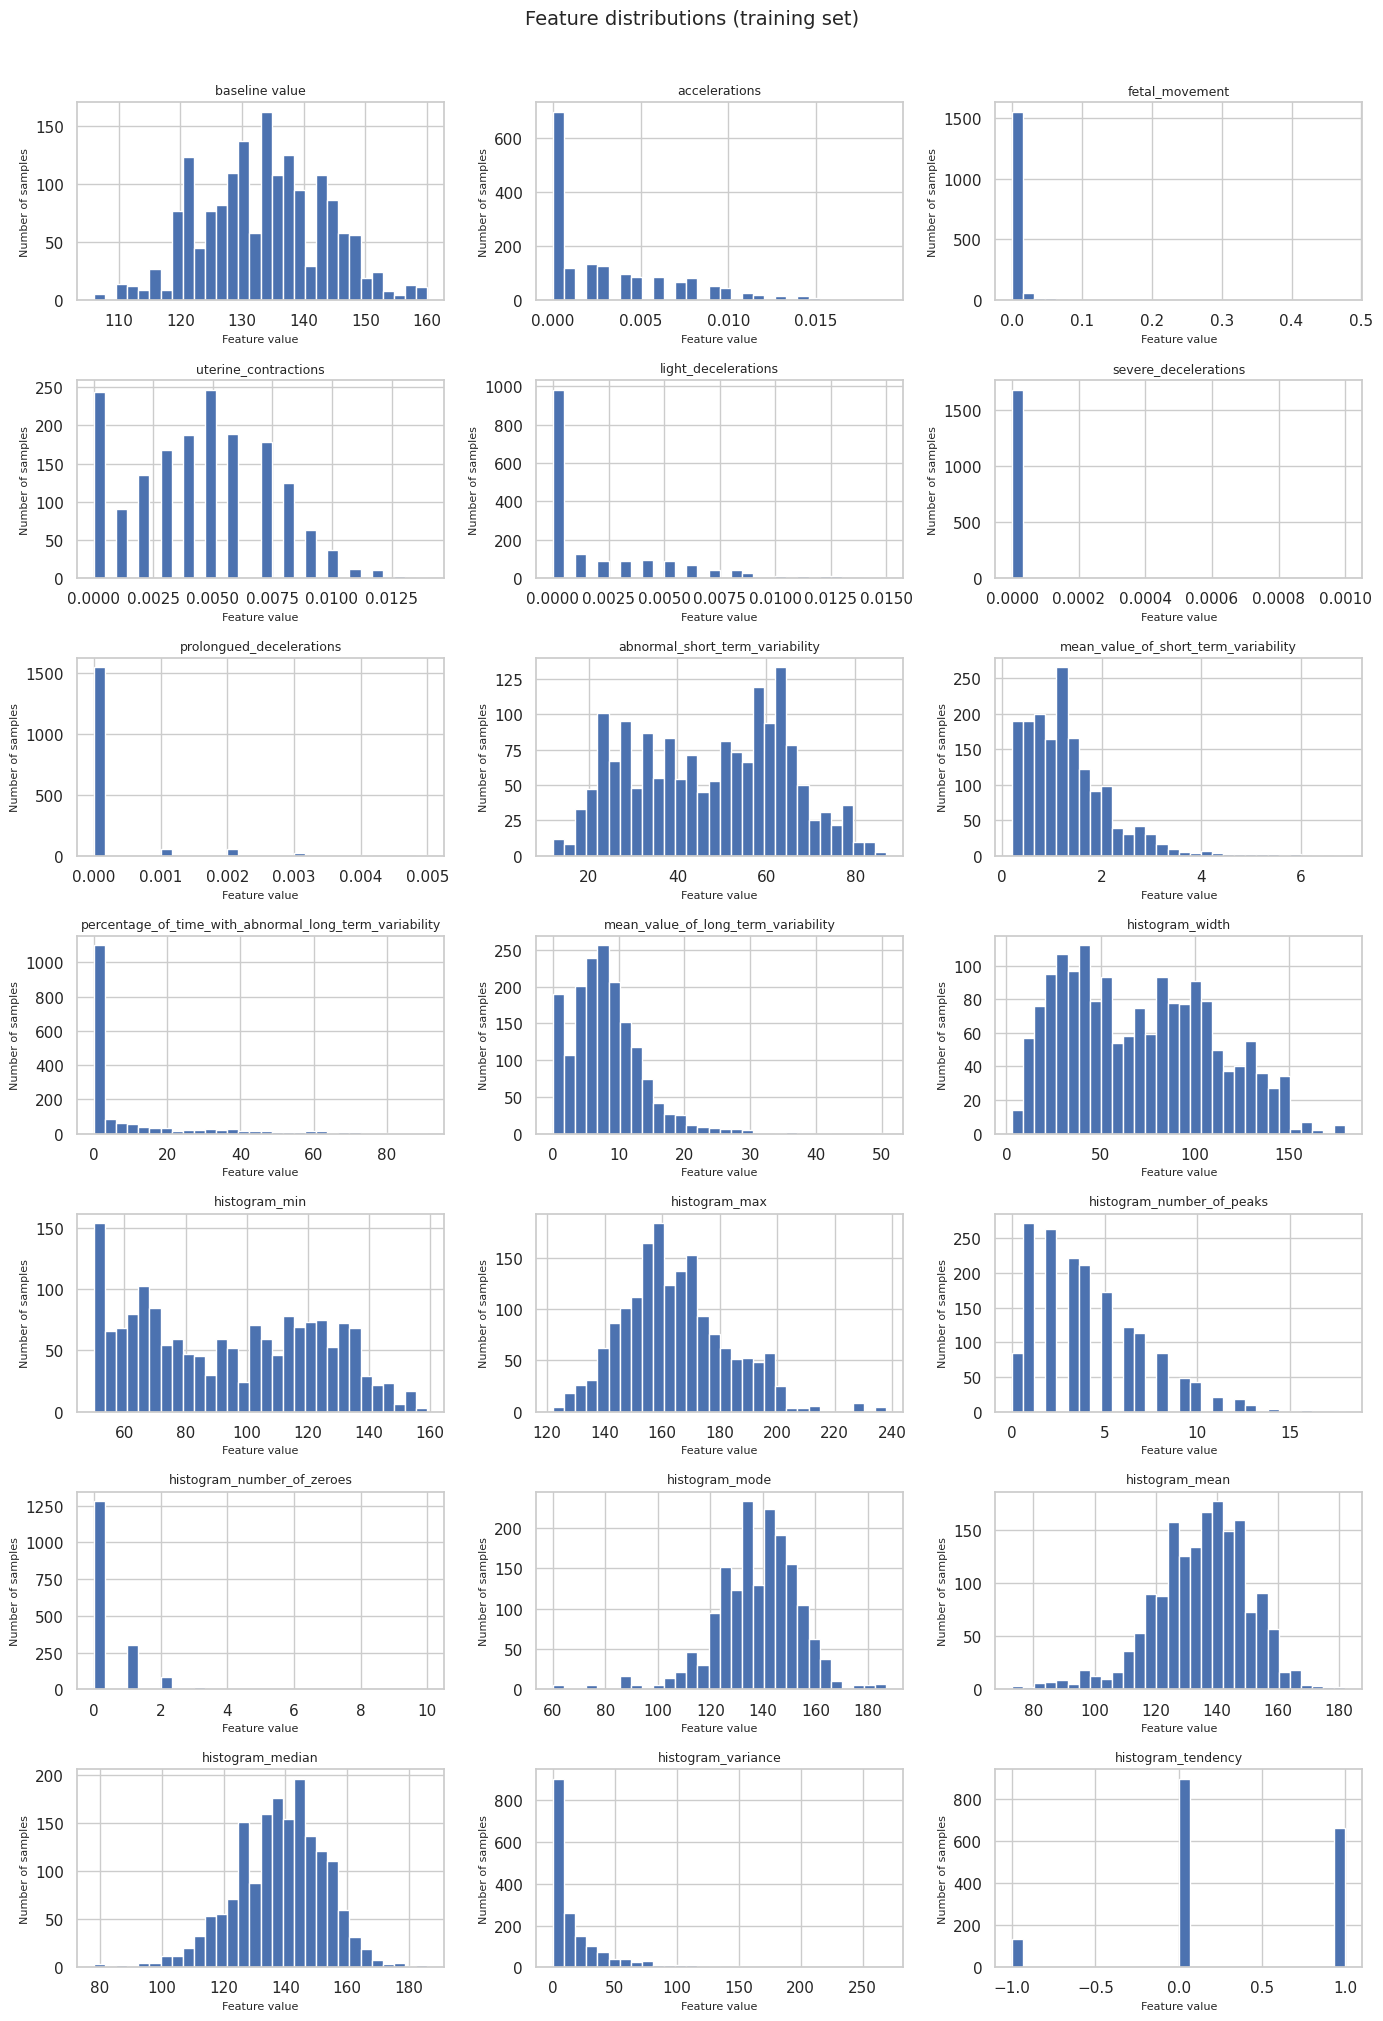

In [9]:
# Histogram of each feature
features = X_train.columns.tolist()

fig, axes = plt.subplots(7, 3, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(X_train[col], bins=30, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Feature value", fontsize=8)
    axes[i].set_ylabel("Number of samples", fontsize=8)

for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.suptitle("Feature distributions (training set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Many features (e.g. `severe_decelerations`, `fetal_movement`, `histogram_number_of_zeroes`) are strongly right-skewed, with most values concentrated near zero and a few observations with high values: this is typical of rare clinical events (e.g. severe heart-rate decelerations), which are infrequent in medical practice but clinically relevant when they occur. The outliers are therefore most likely not errors but genuine clinical signals.

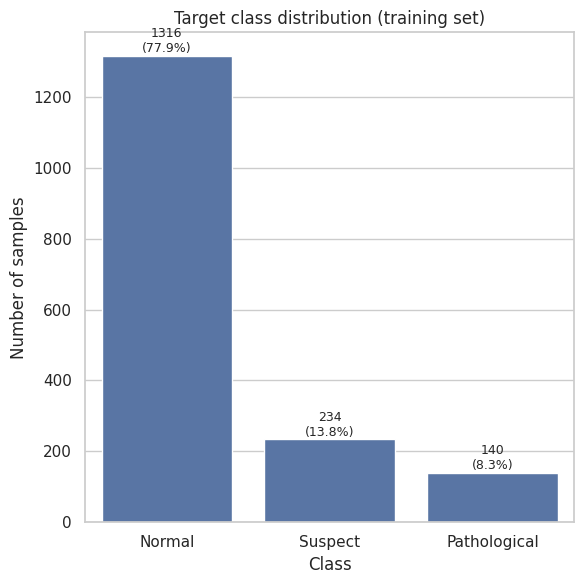

In [10]:
# Target distribution in the training set
fig, ax = plt.subplots(figsize=(6, 6))
order = [1, 2, 3]
labels = {
    1: "Normal",
    2: "Suspect",
    3: "Pathological"
}
counts = y_train.value_counts().reindex(order)
sns.barplot(x=[labels[c] for c in order], y=counts.values, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, f"{v}\n({v/len(y_train)*100:.1f}%)", ha="center", fontsize=9)
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
ax.set_title("Target class distribution (training set)")
plt.tight_layout()
plt.show()

## Outlier identification
### Boxplots: feature vs class
We start with one boxplot per feature, showing the distribution of values split by target class. This lets us visually see which features separate the classes well.

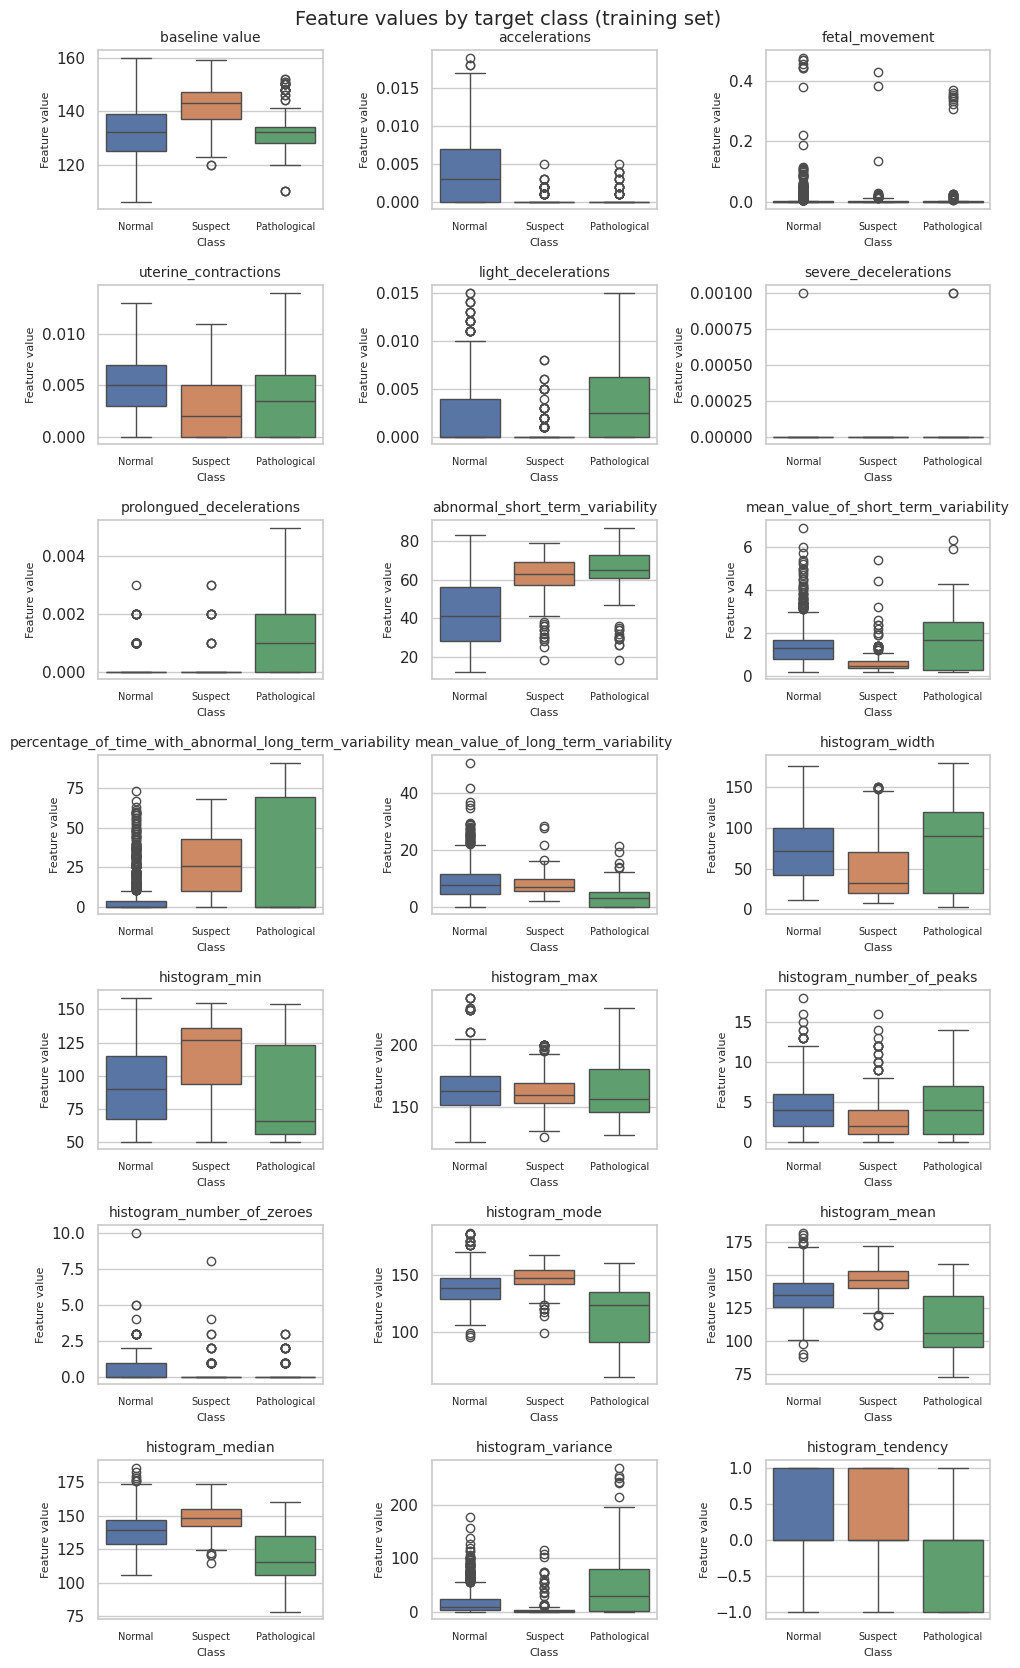

In [11]:
train_full = X_train.copy()
train_full["fetal_health"] = y_train.map(labels)

fig, axes = plt.subplots(7, 3, figsize=(10, 17))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(
        data=train_full,
        x="fetal_health",
        y=col,
        order=["Normal", "Suspect", "Pathological"],
        ax=axes[i],
        hue="fetal_health",
        legend=False
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Class", fontsize=8)
    axes[i].set_ylabel("Feature value", fontsize=8)
    axes[i].tick_params(axis="x", labelsize=7)

plt.suptitle("Feature values by target class (training set)", fontsize=14)
plt.tight_layout()
plt.show()

Outliers can be spotted as the whiskers and isolated points, and they are the same ones the IQR criterion would flag. For some features (e.g. `abnormal_short_term_variability`, `percentage_of_time_with_abnormal_long_term_variability`, `prolongued_decelerations`) the Suspect and Pathological classes show visibly different medians and ranges from Normal: these are probably very informative features for classification (we will confirm this later with feature selection).

### Outlier quantification: IQR method (feature by feature)

For each feature, a value $x$ is flagged as an outlier if it falls outside the interval

$$
\left[\,Q_1 - k\cdot \text{IQR},\;\; Q_3 + k\cdot \text{IQR}\,\right], \qquad \text{IQR} = Q_3 - Q_1, \quad k = 1.5,
$$

where $Q_1$ and $Q_3$ are the first and third quartiles of the feature.

In [12]:
def iqr_outlier_mask(data, k=1.5):
    """Boolean DataFrame: True where a value is outside [Q1 - k*IQR, Q3 + k*IQR] for that feature."""
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (data < lower) | (data > upper)

iqr_mask = iqr_outlier_mask(X_train)
outlier_pct = (iqr_mask.mean() * 100).sort_values(ascending=False).to_frame(name="% outliers (IQR)")
outlier_pct

,% outliers (IQR)
histogram_number_of_zeroes,24.142012
fetal_movement,16.804734
percentage_of_time_with_abnormal_long_term_variability,14.260355
prolongued_decelerations,8.461538
histogram_variance,8.461538
light_decelerations,6.923077
histogram_mode,3.372781
mean_value_of_short_term_variability,3.195266
mean_value_of_long_term_variability,3.076923
histogram_mean,2.011834


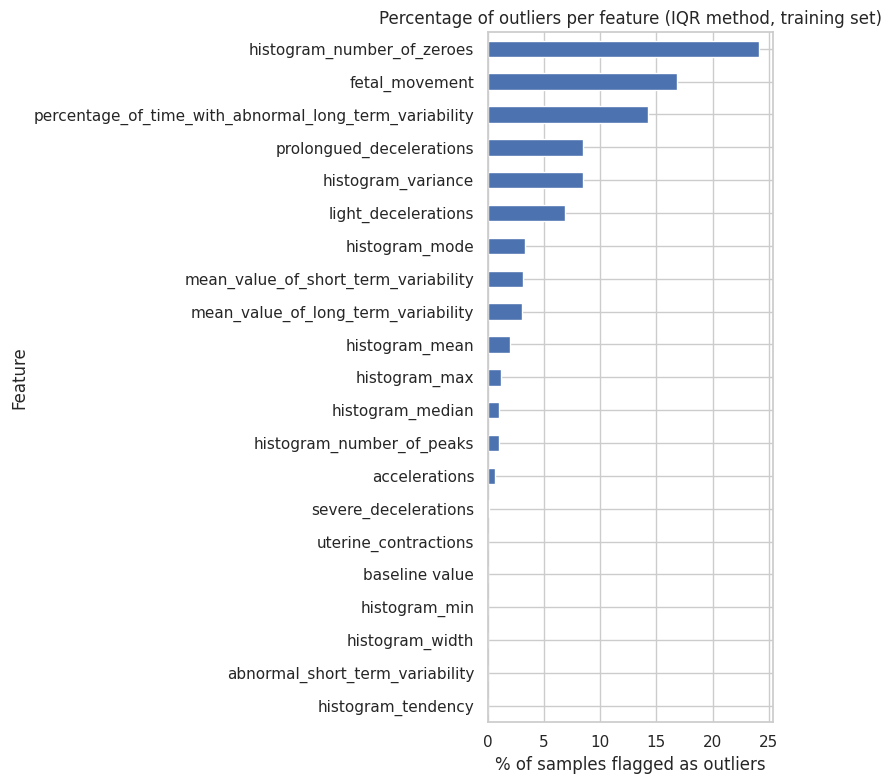

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
outlier_pct["% outliers (IQR)"].plot(kind="barh", ax=ax)
ax.set_xlabel("% of samples flagged as outliers")
ax.set_ylabel("Feature")
ax.set_title("Percentage of outliers per feature (IQR method, training set)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Outlier quantification: model-based method (Isolation Forest)
We fit an `IsolationForest` on the training set without standardizing it, since it relies on tree splits and is insensitive to scale. The `contamination` parameter is the expected fraction of outliers: we use `'auto'`, which lets the algorithm set the threshold on the anomaly score, avoiding an arbitrary guess of the percentage on our side.

In [14]:
# Isolation Forest
iso_forest = IsolationForest(random_state=RANDOM_STATE, contamination="auto", n_jobs=1)
outlier_labels = iso_forest.fit_predict(X_train)

pct_multivariate = (outlier_labels == -1).mean() * 100
print(f"Isolation Forest: {pct_multivariate:.2f}% of training samples flagged as multivariate outliers")

Isolation Forest: 9.53% of training samples flagged as multivariate outliers


### Overlap between the two outlier detection methods
So far the two methods have only been described side by side. To quantify how much they agree, we compare the sets of *rows* flagged as anomalous. Since IQR works feature by feature, a row is called an IQR outlier if it is flagged on at least one feature (a very permissive definition) or on at least 3 features (a stricter one). We report the size of the intersection, the Jaccard index $J = |A\cap B| / |A\cup B|$, and the overlap we would expect by pure chance if the two methods were independent, $|A|\cdot|B|/N$.

In [15]:
rows_if = pd.Series(outlier_labels == -1, index=X_train.index)
rows_iqr_any = iqr_mask.any(axis=1)
rows_iqr_3plus = iqr_mask.sum(axis=1) >= 3

def overlap_report(a, b, name_a, name_b):
    n = len(a)
    inter = (a & b).sum()
    union = (a | b).sum()
    return {
        "Method A": name_a,
        "Method B": name_b,
        "|A|": int(a.sum()),
        "|B|": int(b.sum()),
        "|A ∩ B|": int(inter),
        "Expected by chance": round(a.sum() * b.sum() / n, 1),
        "Jaccard": round(inter / union, 3),
        "% of B also in A": round(100 * inter / b.sum(), 1),
    }

overlap_df = pd.DataFrame([
    overlap_report(rows_iqr_any, rows_if, "IQR (>=1 feature)", "Isolation Forest"),
    overlap_report(rows_iqr_3plus, rows_if, "IQR (>=3 features)", "Isolation Forest"),
])
overlap_df

,Method A,Method B,|A|,|B|,|A ∩ B|,Expected by chance,Jaccard,% of B also in A
0,IQR (>=1 feature),Isolation Forest,975,161,155,92.9,0.158,96.3
1,IQR (>=3 features),Isolation Forest,139,161,99,13.2,0.493,61.5


In [16]:
# Class composition of the rows flagged by Isolation Forest vs the whole training set
comp = pd.DataFrame({
    "All training rows": y_train.map(labels).value_counts(normalize=True) * 100,
    "Isolation Forest outliers": y_train[rows_if].map(labels).value_counts(normalize=True) * 100,
    "IQR outliers (>=3 features)": y_train[rows_iqr_3plus].map(labels).value_counts(normalize=True) * 100,
}).reindex(["Normal", "Suspect", "Pathological"]).round(1)
comp.index.name = "Class (% of each group)"
comp

,All training rows,Isolation Forest outliers,IQR outliers (>=3 features)
Class (% of each group),,,
Normal,77.9,50.3,52.5
Suspect,13.8,8.7,6.5
Pathological,8.3,41.0,41.0


### Final comment on outlier detection
- With the IQR method, some features (especially those linked to rare clinical events) show fairly high outlier percentages (over 10-15%). This is expected: they are strongly skewed variables, so the IQR criterion, designed for relatively symmetric distributions, tends to over-report values that are in fact part of normal clinical variability.
- With Isolation Forest the percentage of outliers is lower and probably more realistic, since it looks at all features jointly rather than one at a time.
- The overlap table above quantifies the agreement. The permissive IQR definition (at least one feature) flags more than half of the rows, so its overlap with Isolation Forest is only moderately above chance (Jaccard $\approx 0.16$). With the stricter definition (at least 3 features) the agreement is much stronger: 99 of the 161 Isolation Forest outliers are also flagged, against about 13 expected by chance (Jaccard $\approx 0.49$). The two methods therefore capture related but distinct notions of "anomalous". The class-composition table also shows that the flagged rows are strongly over-represented among Pathological samples (about 41% of the outliers versus about 8% of the training set), which supports the decision below.

#### We will not remove the outliers.
There are two reasons:

- Domain: in a medical context like this one, an extreme value is often precisely the signal that indicates a suspect or pathological patient rather than a healthy one. Removing these values would mean systematically removing the most clinically critical cases.
- Statistical: the dataset is already relatively small and the minority classes (Suspect, Pathological) have few samples. Removing outliers would disproportionately hit these classes, worsening the imbalance even further and reducing the data available to learn from.

## Feature standardization

As observed earlier, the features have very different scales. This is a problem for many of the machine learning algorithms we will try, so we use `StandardScaler` to transform each feature so that it has mean 0 and standard deviation 1:

$$
z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}
$$

We fit the `StandardScaler` on the training set only and then apply the same parameters ($\mu_{\text{train}}$, $\sigma_{\text{train}}$) to the test set, without recomputing them, to avoid data leakage.
Standardizing the target (`fetal_health`) would make no sense, since it is a categorical variable rather than a continuous one, so we keep it separate from `X_train` and `X_test`.

In [17]:
scaler = StandardScaler()

# fit on the training set
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# transform the test set using the training mean and std
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Max |mean| of the features in the training set after scaling:", X_train_scaled.mean().round(3).abs().max())
print("\nStandard deviation of the features in the training set after scaling:")
print(X_train_scaled.std().round(3).describe()[["min", "max"]])
print("\nTraining set (first 5 features):")
print(X_train_scaled.describe().T[["mean", "std"]].head())
print("\nTest set (first 5 features):")
print(X_test_scaled.describe().T[["mean", "std"]].head())

Max |mean| of the features in the training set after scaling: 0.0

Standard deviation of the features in the training set after scaling:
min    1.0
max    1.0
dtype: float64

Training set (first 5 features):
                              mean       std
baseline value       -3.636802e-16  1.000296
accelerations         5.518268e-17  1.000296
fetal_movement       -1.471538e-17  1.000296
uterine_contractions  1.955044e-16  1.000296
light_decelerations  -1.534604e-16  1.000296

Test set (first 5 features):
                          mean       std
baseline value       -0.024320  1.001028
accelerations        -0.036945  0.969614
fetal_movement        0.085791  1.298832
uterine_contractions -0.058917  1.071222
light_decelerations   0.017822  1.011349


As expected, on the training set we get a mean of about zero and a standard deviation of about 1 for all features, while on the test set the values are less close to these targets: this confirms that no leakage occurred.

## Is the dataset balanced?
Let us recall the numbers seen earlier:

In [18]:
counts = y_train.value_counts().sort_index()
percentages = y_train.value_counts(normalize=True).sort_index() * 100

balance_df = pd.DataFrame({"Count": counts, "Percentage": percentages.round(1)})
balance_df.index = balance_df.index.map(labels)
balance_df

,Count,Percentage
fetal_health,,
Normal,1316,77.9
Suspect,234,13.8
Pathological,140,8.3


The dataset is not balanced: the Normal class accounts for about 78% of the training set, against about 14% for Suspect and 8% for Pathological. A model trained on imbalanced data tends to "learn" to favour the majority class in order to minimize the overall average error, obtained simply by predicting Normal almost always.
##### Possible solutions:
- Oversampling the minority classes (e.g. SMOTE): generates new synthetic data by interpolating between neighbouring points in the feature space. The risk is that, with very few original samples, the synthetic examples will be very similar to each other, leading to overfitting.
- Undersampling: reduces the number of Normal examples to equalize the classes. Discarding down to ~130 per class would mean eliminating most of the available data, a very high price in terms of lost information.
- Class weighting (`class_weight='balanced'`): this method does not touch the data, does not introduce synthetic data and does not discard real data, but assigns a higher weight to the minority classes so that their total contribution balances that of the others. For a class $c$ with $N_c$ samples, out of $N$ total samples and $K$ classes:

$$
w_c = \frac{N}{K \cdot N_c}
$$

  (natively supported by many sklearn classifiers, e.g. logistic regression, SVM, Random Forest).

In [19]:
# Class balancing weights
class_weight = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weight.round(2)))
print("Class weights (class_weight='balanced'):")
for cls, w in class_weight_dict.items():
    print(f"Class {cls} ({labels[cls]}): weight = {w}")

Class weights (class_weight='balanced'):
Class 1 (Normal): weight = 0.43
Class 2 (Suspect): weight = 2.41
Class 3 (Pathological): weight = 4.02


The Pathological class (the rarest) receives a higher weight than the others: during training, a mistake on an example of this class will "cost" the model much more than a mistake on a Normal example, counterbalancing the imbalance without touching the data.

## Correlation matrix
Why we care: if two features are highly correlated with each other, they carry redundant information. For linear models, strongly correlated features cause multicollinearity, which makes the coefficient estimates unstable (small changes in the data can drastically change the estimated coefficients while leaving the predictions almost unchanged). For interpretability too, it is worth reducing redundancy.

We use the Pearson correlation coefficient:

$$
r_{ij} = \frac{\operatorname{cov}(X_i, X_j)}{\sigma_{X_i}\,\sigma_{X_j}}
$$

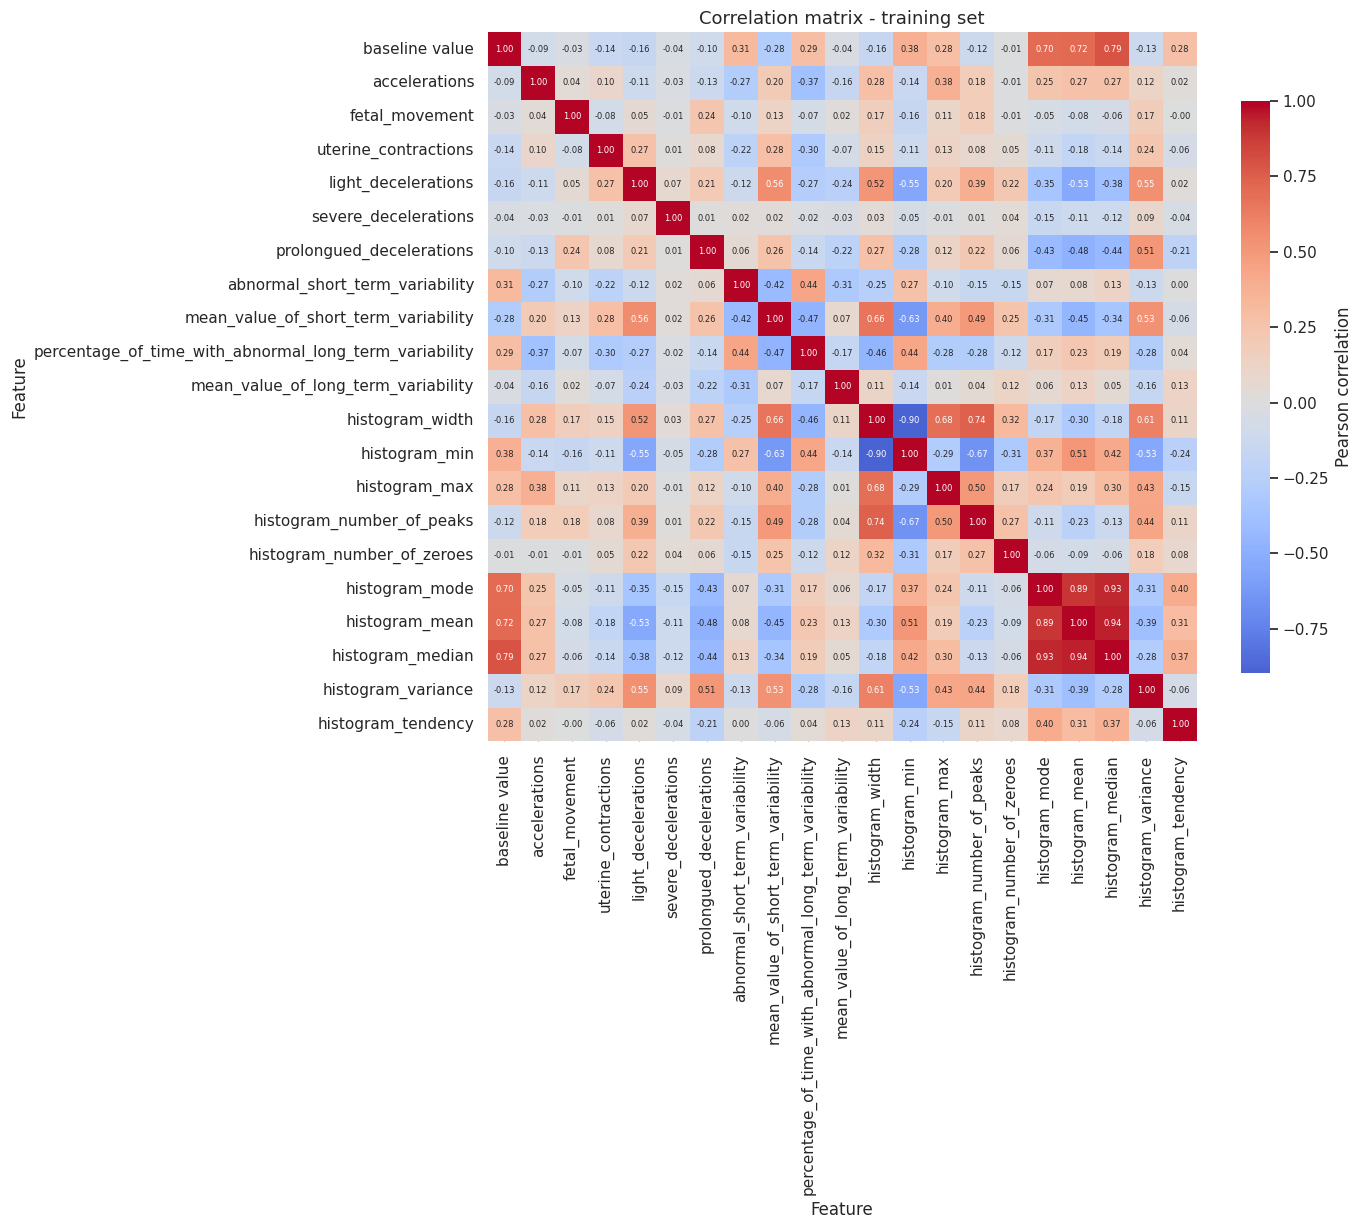

In [20]:
corr_matrix = X_train.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", annot_kws={"size": 6}, cmap="coolwarm", center=0,
            ax=ax, square=True, cbar_kws={"shrink": 0.8, "label": "Pearson correlation"})
ax.set_xlabel("Feature")
ax.set_ylabel("Feature")
ax.set_title("Correlation matrix - training set", fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
# Extract highly correlated pairs, avoiding duplicates (a|b / b|a) and the diagonal
threshold = 0.85
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr = corr_pairs[corr_pairs["correlation"].abs() >= threshold].sort_values(
    "correlation", key=abs, ascending=False
)
high_corr

,feature_1,feature_2,correlation
375,histogram_mean,histogram_median,0.944859
354,histogram_mode,histogram_median,0.930341
243,histogram_width,histogram_min,-0.896329
353,histogram_mode,histogram_mean,0.891057


We visualize the most correlated pair with a simple scatter plot coloured by class, so that we can see both the strength of the correlation and whether it varies across classes.

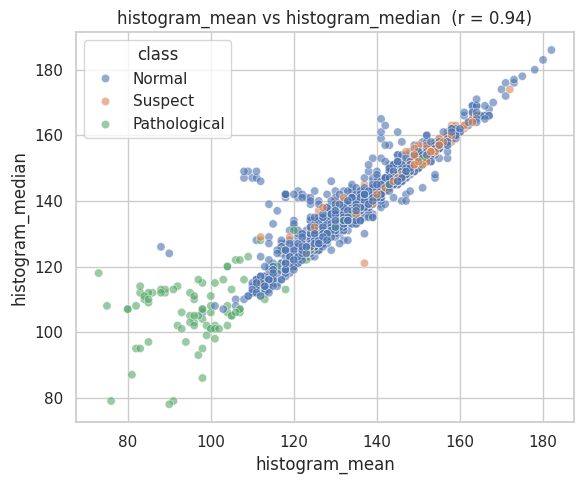

In [22]:
if len(high_corr) > 0:
    top_pair = high_corr.iloc[0]
    f1, f2, r = top_pair["feature_1"], top_pair["feature_2"], top_pair["correlation"]

    fig, ax = plt.subplots(figsize=(6, 5))
    scatter_df = X_train[[f1, f2]].copy()
    scatter_df["class"] = y_train.map(labels).values
    sns.scatterplot(data=scatter_df, x=f1, y=f2, hue="class", alpha=0.6, ax=ax,
                    hue_order=["Normal", "Suspect", "Pathological"])
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.set_title(f"{f1} vs {f2}  (r = {r:.2f})")
    plt.tight_layout()
    plt.show()
else:
    print("No pair exceeds the chosen correlation threshold.")

##### Interpretation and decision
Looking at the matrix, the most strongly correlated pairs are typically those derived from the same fetal heart rate histogram (`histogram_mean`, `histogram_median`, `histogram_mode`, with $|r|$ between 0.89 and 0.94) and the pair `histogram_min`/`histogram_width`. This makes perfect sense from a domain point of view: they are all statistics computed on the same distribution (the histogram of heart rate values), so it is natural that they move together.

Decision: for the pairs with $|r| \geq 0.85$ we could consider dropping one of the two features, keeping the one with the more direct clinical interpretation or the one that turns out to be more informative in feature selection. We do not drop anything definitively at this stage, so as not to throw away a feature based only on its correlation with another one, ignoring how predictive it is for the target.

## Feature selection
Feature selection is a data-driven step in which we assess which features are the most important.
##### Mutual Information vs Chi-square
- Mutual information measures how much information knowing a feature $X$ gives us about the target $Y$:

$$
I(X;Y) = \sum_{x}\sum_{y} p(x,y)\,\log\frac{p(x,y)}{p(x)\,p(y)}
$$

  Unlike correlation, it also captures non-linear relationships, and it is zero only if the two variables are statistically independent. It is therefore a more general and flexible measure that does not depend on the shape of the relationship.
- Chi-square is a statistical test of independence between two categorical variables, i.e. it measures how far the observed distribution deviates from the one expected under independence from the target:

$$
\chi^2 = \sum_i \frac{(O_i - E_i)^2}{E_i}
$$

  It requires non-negative features. Our features are all non-negative by nature, but we cannot use `X_train_scaled`, since after `StandardScaler` it contains negative values. We therefore use a MinMax-scaled version (which keeps everything $\geq 0$) or the raw, non-standardized data.

We then use `SelectKBest`, which, given a scoring function (Mutual Information or Chi-square), ranks the features by score and keeps the best $K$.

In [23]:
K = 10  # number of features to select, for comparison purposes

# Mutual information
mi_selector = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=RANDOM_STATE), k=K)
mi_selector.fit(X_train, y_train)
mi_scores = pd.Series(mi_selector.scores_, index=X_train.columns).sort_values(ascending=False)
mi_top_k = mi_scores.head(K).index.tolist()

print("Top features by Mutual Information:")
mi_scores.head(K)

Top features by Mutual Information:


mean_value_of_short_term_variability                      0.207995
percentage_of_time_with_abnormal_long_term_variability    0.192261
abnormal_short_term_variability                           0.181123
histogram_mean                                            0.178741
histogram_median                                          0.156177
accelerations                                             0.142411
histogram_mode                                            0.142077
histogram_variance                                        0.135499
histogram_width                                           0.126271
histogram_min                                             0.124595
dtype: float64

In [24]:
# Chi-square
# MinMaxScaler is used to make all the data non-negative
minmax_scaler = MinMaxScaler()
X_train_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

chi2_selector = SelectKBest(score_func=chi2, k=K)
chi2_selector.fit(X_train_minmax, y_train)

chi2_scores = pd.Series(chi2_selector.scores_, index=X_train.columns).sort_values(ascending=False)
chi2_top_k = chi2_scores.head(K).index.tolist()

print("Top features by Chi-square:")
chi2_scores.head(K)

Top features by Chi-square:


prolongued_decelerations                                  241.206504
percentage_of_time_with_abnormal_long_term_variability    149.975829
accelerations                                              65.439875
abnormal_short_term_variability                            44.893511
histogram_variance                                         37.760074
light_decelerations                                        31.851860
histogram_min                                              24.214545
mean_value_of_short_term_variability                       17.803940
uterine_contractions                                       17.497026
histogram_mean                                             13.595515
dtype: float64

In [25]:
comparison_fs = pd.DataFrame({
    "Rank MI": mi_scores.rank(ascending=False).astype(int),
    "Score MI": mi_scores.round(3),
    "Rank Chi2": chi2_scores.rank(ascending=False).astype(int),
    "Score Chi2": chi2_scores.round(1),
}).sort_values("Rank MI")

comparison_fs[f"In top-{K} of both"] = comparison_fs.index.isin(mi_top_k) & comparison_fs.index.isin(chi2_top_k)
comparison_fs

,Rank MI,Score MI,Rank Chi2,Score Chi2,In top-10 of both
mean_value_of_short_term_variability,1,0.208,8,17.8,True
percentage_of_time_with_abnormal_long_term_variability,2,0.192,2,150.0,True
abnormal_short_term_variability,3,0.181,4,44.9,True
histogram_mean,4,0.179,10,13.6,True
histogram_median,5,0.156,14,10.3,False
accelerations,6,0.142,3,65.4,True
histogram_mode,7,0.142,15,9.3,False
histogram_variance,8,0.135,5,37.8,True
histogram_width,9,0.126,13,10.5,False
histogram_min,10,0.125,7,24.2,True


In [26]:
overlap = set(mi_top_k) & set(chi2_top_k)
print(f"Features shared by the top-{K} of both methods: {len(overlap)}/{K}")
print(sorted(overlap))

Features shared by the top-10 of both methods: 7/10
['abnormal_short_term_variability', 'accelerations', 'histogram_mean', 'histogram_min', 'histogram_variance', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability']


##### Comparison and interpretation
The two methods are based on different principles (information-theoretic vs a statistical independence test on non-negative/discretized data), so we do not expect perfect agreement, but substantial agreement on the strongest features is a good sign of robustness: it means the predictive signal is not an artefact of either method.

In our run the two methods share 7 of their top-10 features. Both identify as very informative the features directly linked to fetal heart rate variability, such as `abnormal_short_term_variability`, `percentage_of_time_with_abnormal_long_term_variability`, `prolongued_decelerations`, and some histogram features (`histogram_min`, `histogram_variance`), consistently with what we had already inferred from the boxplots, where these same features showed the sharpest differences between the three classes.

The features that instead appear at the bottom of both rankings (e.g. `fetal_movement`, `histogram_number_of_peaks`) are good candidates to be discarded in a further selection stage for the final model, to be confirmed anyway through their actual performance in the models (e.g. with the feature importance of a Random Forest, or selection via cross-validation).

Important methodological note: the feature selection performed here is exploratory. Since the selected subset will later be used to train models, the score computed on the whole training set introduces a mild but real form of leakage between the cross-validation folds (the selection saw the validation folds' labels). It would be cleaner to integrate the selection inside the cross-validation pipeline (`Pipeline` + `SelectKBest`), refitting it at every fold. We flag this in the Limitations section.

## Choice of evaluation metrics
Accuracy (the percentage of correct predictions out of the total),

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN},
$$

is the most intuitive metric, but on an imbalanced dataset like ours (~78% Normal, ~14% Suspect, ~8% Pathological) it can be extremely misleading. A classifier that always predicted Normal, having learned absolutely nothing, would already obtain about 78% accuracy: a number that looks good but hides the fact that the model would systematically get all the minority classes wrong, which are precisely the clinically most important ones to detect (a Pathological fetus mistaken for Normal is the most dangerous possible error in this context).

For each class $c$ we define precision, recall and F1:

$$
P_c = \frac{TP_c}{TP_c + FP_c}, \qquad
R_c = \frac{TP_c}{TP_c + FN_c}, \qquad
F1_c = \frac{2\,P_c\,R_c}{P_c + R_c}
$$

We will therefore use **macro-averaged F1** as the main metric to guide automatic decisions (spot check and hyperparameter tuning via cross-validation):

$$
F1_{\text{macro}} = \frac{1}{K}\sum_{c=1}^{K} F1_c, \qquad K = 3
$$

because:
- it treats the three classes equally, regardless of their support, consistently with the clinical goal of not neglecting the minority classes;
- it is a single scalar metric, convenient to compare and rank different models automatically (e.g. inside `GridSearchCV`).

In the final evaluation on the test set, however, we will not stop at F1-macro alone: we will also look at the full classification report (precision/recall/F1 per class) and the confusion matrix, paying particular attention to the recall of the Pathological class, which in our application context is the most costly risk to minimize.

**Baseline.** The accuracy argument above stays purely narrative unless we measure it. We therefore fit an explicit baseline (a `DummyClassifier`) and report its F1-macro next to the trained models: any model that does not clearly beat this number has learned nothing useful.

## Choice of models
The problem requires models that support multiclass classification (Normal/Suspect/Pathological). The models we will use are:

- Logistic Regression: finds a linear combination of the features that best separates the classes. It requires standardized features.
- Random Forest: an ensemble of decision trees, each trained on a bootstrap sample of the training set and on a random subset of features at each split. It does not require scaled features.
- K-Nearest Neighbors: makes predictions based on the $k$ closest examples in the training set. Being distance-based, it requires scaled features.

## Preprocessing inside a Pipeline
Earlier we standardized the whole `X_train`; this is fine for exploratory analysis, but for cross-validation, which we will use from here on, at every iteration a part of the data becomes the "validation fold". If the scaler is fitted only once on the whole training set, a mild form of leakage between folds is created.
The solution we adopt is to wrap `StandardScaler` inside a `Pipeline` and then pass it to `cross_validate`/`GridSearchCV`. For Random Forest scaling has no effect, but including it anyway does no harm and keeps the code uniform across models.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score
)

SCORING = "f1_macro"  # reference metric for model selection and tuning
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CLASS_NAMES = ["Normal", "Suspect", "Pathological"]

We use `StratifiedKFold` rather than a plain `KFold` to keep, in every fold, the initial class proportions of the full dataset.

## Baseline model
Before training any real model we need a reference point for our chosen metric. We use two `DummyClassifier` strategies:

- `most_frequent`: always predicts the majority class (Normal);
- `stratified`: predicts random labels drawn according to the class proportions of the training set (a "random" classifier that is aware of the imbalance).

Both are evaluated with the same 5-fold stratified cross-validation and the same F1-macro metric that will be used for all the other models.

In [28]:
def spot_check(models, X, y):
    """Cross-validate each model, returning the per-fold scores and a summary table with timings."""
    cv_scores, rows = {}, []
    for name, pipe in models.items():
        res = cross_validate(pipe, X, y, cv=CV, scoring=SCORING, n_jobs=1)
        cv_scores[name] = res["test_score"]
        rows.append({
            "Model": name,
            "F1-macro (CV mean)": res["test_score"].mean(),
            "Std": res["test_score"].std(),
            "Fit time / fold (s)": res["fit_time"].mean(),
            "Predict time / fold (s)": res["score_time"].mean(),
        })
        print(f"{name:26s}  F1-macro: {res['test_score'].mean():.4f}  (+/- {res['test_score'].std():.4f})"
              f"  |  fit {res['fit_time'].mean():.3f}s/fold, predict {res['score_time'].mean():.3f}s/fold")
    return cv_scores, pd.DataFrame(rows).set_index("Model")

baseline_models = {
    "Baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Baseline (stratified random)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
}

baseline_cv_scores, baseline_cv_table = spot_check(baseline_models, X_train, y_train)

# Test-set F1-macro of the baselines (fitted on the training set only)
baseline_test = {}
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_test[name] = {
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "recall_pathological": recall_score(y_test, y_pred, labels=[3], average=None)[0],
    }
    print(f"{name:26s}  F1-macro on TEST: {baseline_test[name]['f1_macro']:.4f}  |  "
          f"recall Pathological: {baseline_test[name]['recall_pathological']:.2f}")

Baseline (most frequent)    F1-macro: 0.2919  (+/- 0.0002)  |  fit 0.001s/fold, predict 0.002s/fold
Baseline (stratified random)  F1-macro: 0.3088  (+/- 0.0285)  |  fit 0.001s/fold, predict 0.002s/fold
Baseline (most frequent)    F1-macro on TEST: 0.2922  |  recall Pathological: 0.00
Baseline (stratified random)  F1-macro on TEST: 0.2775  |  recall Pathological: 0.03


The majority-class baseline reaches a high accuracy but a very low F1-macro, exactly as argued above; this is the number that every trained model has to beat.

## Spot check
The spot check is a quick, coarse comparison between different algorithms, with the aim of getting an idea of which model families look promising on this problem.
We define the three models as pipelines and evaluate each of them with `cross_validate`, using the `StratifiedKFold` defined above and F1-macro as the metric. `cross_validate` also returns the fit and predict times, which we keep as a secondary comparison criterion.

In [29]:
# Spot check with ALL the features (Setup A)
models_spot1 = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),  # included for pipeline uniformity
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())  # default k = 5
    ])
}

spot_check_results, spot_check_table1 = spot_check(models_spot1, X_train, y_train)

LogisticRegression          F1-macro: 0.7863  (+/- 0.0380)  |  fit 0.042s/fold, predict 0.004s/fold


RandomForest                F1-macro: 0.8919  (+/- 0.0158)  |  fit 0.257s/fold, predict 0.014s/fold
KNN                         F1-macro: 0.7912  (+/- 0.0284)  |  fit 0.005s/fold, predict 0.016s/fold


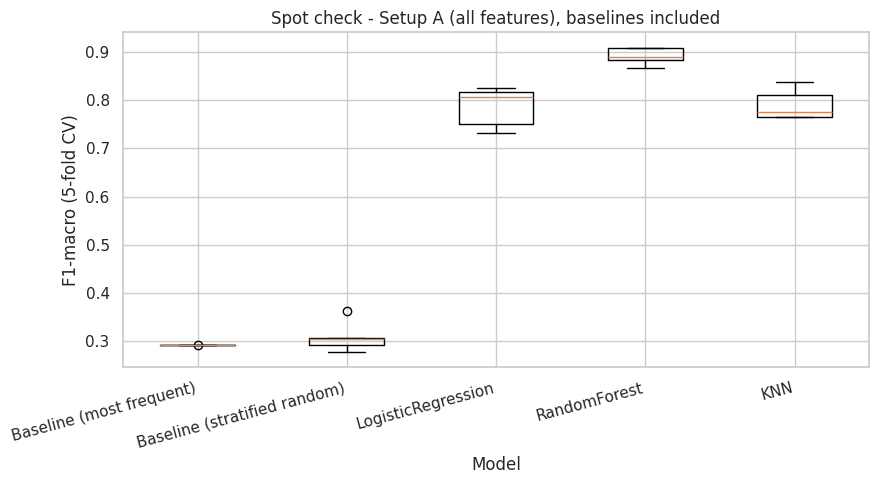

In [30]:
def plot_spot_check(results_models, results_baselines, title):
    all_results = {**results_baselines, **results_models}
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot(list(all_results.values()))
    ax.set_xticklabels(list(all_results.keys()), rotation=15, ha="right")
    ax.set_xlabel("Model")
    ax.set_ylabel("F1-macro (5-fold CV)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_spot_check(spot_check_results, baseline_cv_scores, "Spot check - Setup A (all features), baselines included")

In [31]:
ranking_setup_a = pd.Series({k: v.mean() for k, v in spot_check_results.items()}).sort_values(ascending=False)
print("Model ranking (Setup A):")
print(ranking_setup_a)

Model ranking (Setup A):
RandomForest          0.891935
KNN                   0.791219
LogisticRegression    0.786271
dtype: float64


## Hyperparameter tuning (GridSearchCV)
`GridSearchCV` performs an exhaustive search trying every possible combination of hyperparameters specified in a grid (`param_grid`), evaluating each combination with the same cross-validation strategy used for the spot check, and finally refits the model with the best combination on the whole training set (`refit=True`).
We also record the wall-clock time of every search (`time.perf_counter`), since tuning cost is a practical constraint when moving to heavier models. The time of the final refit is available as `refit_time_`.

In [32]:
param_grids = {
    "LogisticRegression": {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__penalty": ["l2"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 400],
        "clf__max_depth": [None, 5, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4],
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 11, 13, 17, 19],
        "clf__weights": ["uniform", "distance"],
    },
}

def tune_models(model_names, models_dict, X, y):
    """Run GridSearchCV on the given models and return the fitted searches (with their tuning time)."""
    tuned = {}
    for name in model_names:
        grid = GridSearchCV(
            estimator=models_dict[name],
            param_grid=param_grids[name],
            scoring=SCORING,
            cv=CV,
            n_jobs=-1,
        )
        t0 = time.perf_counter()
        grid.fit(X, y)
        grid.tuning_time_ = time.perf_counter() - t0
        tuned[name] = grid
        print(f"{name:20s}  Best F1-macro (CV): {grid.best_score_:.4f}  |  Tuning time: {grid.tuning_time_:6.1f}s  |  Best parameters: {grid.best_params_}")
    return tuned

tuned_setup_a = tune_models(ranking_setup_a.index.tolist(), models_spot1, X_train, y_train)

RandomForest          Best F1-macro (CV): 0.8936  |  Tuning time:   98.9s  |  Best parameters: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}


KNN                   Best F1-macro (CV): 0.8308  |  Tuning time:    1.0s  |  Best parameters: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}


LogisticRegression    Best F1-macro (CV): 0.7863  |  Tuning time:    0.9s  |  Best parameters: {'clf__C': 1, 'clf__penalty': 'l2'}


## Final evaluation on the test set

RandomForest (Setup A) - F1-macro on the TEST set: 0.8897  (inference on 423 samples: 26.2 ms)
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97       330
     Suspect       0.86      0.83      0.84        58
Pathological       0.86      0.86      0.86        35

    accuracy                           0.94       423
   macro avg       0.89      0.89      0.89       423
weighted avg       0.94      0.94      0.94       423



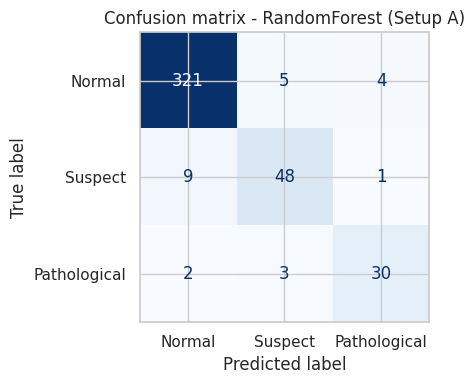

KNN (Setup A) - F1-macro on the TEST set: 0.8363  (inference on 423 samples: 8.1 ms)
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.96       330
     Suspect       0.83      0.67      0.74        58
Pathological       0.74      0.89      0.81        35

    accuracy                           0.92       423
   macro avg       0.84      0.84      0.84       423
weighted avg       0.92      0.92      0.92       423



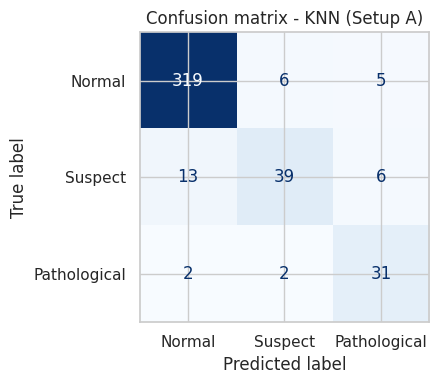

LogisticRegression (Setup A) - F1-macro on the TEST set: 0.7227  (inference on 423 samples: 1.9 ms)
              precision    recall  f1-score   support

      Normal       0.98      0.86      0.92       330
     Suspect       0.51      0.74      0.60        58
Pathological       0.56      0.77      0.65        35

    accuracy                           0.84       423
   macro avg       0.68      0.79      0.72       423
weighted avg       0.88      0.84      0.85       423



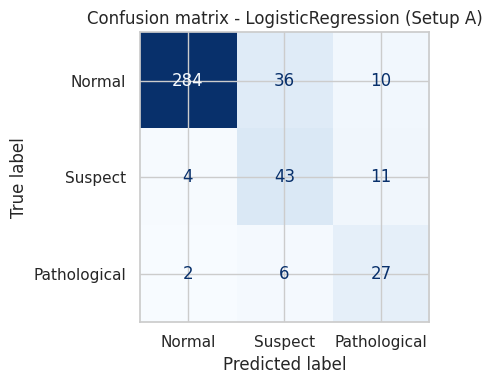

In [33]:
def evaluate_on_test(tuned_models, X_te, y_te, title_suffix=""):
    """Evaluate the tuned models on the test set; returns F1-macro, Pathological recall and timings."""
    results = {}
    for name, grid in tuned_models.items():
        best_model = grid.best_estimator_

        t0 = time.perf_counter()
        y_pred = best_model.predict(X_te)
        inference_ms = (time.perf_counter() - t0) * 1000

        f1_macro_test = f1_score(y_te, y_pred, average="macro")
        rec_patho = recall_score(y_te, y_pred, labels=[3], average=None)[0]
        results[name] = {
            "f1_macro": f1_macro_test,
            "recall_pathological": rec_patho,
            "tuning_time_s": grid.tuning_time_,
            "refit_time_s": grid.refit_time_,
            "inference_ms": inference_ms,
        }

        print(f"{name} {title_suffix} - F1-macro on the TEST set: {f1_macro_test:.4f}"
              f"  (inference on {len(X_te)} samples: {inference_ms:.1f} ms)")
        print(classification_report(y_te, y_pred, target_names=CLASS_NAMES))

        fig, ax = plt.subplots(figsize=(5, 4))
        cm = confusion_matrix(y_te, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_title(f"Confusion matrix - {name} {title_suffix}")
        plt.tight_layout()
        plt.show()

    return results

test_results_a = evaluate_on_test(tuned_setup_a, X_test, y_test, title_suffix="(Setup A)")

##### Conclusion for the models with all the features
Comparing the test-set F1-macro of the tuned models, we can tell which one generalizes best to unseen data. Beyond the summary number, the **confusion matrix** and the **classification report** tell us something more operational: in particular it is worth checking the **recall of the `Pathological` class** for each model, which is the most relevant metric from the clinical point of view, because it represents the model's ability not to miss the most severe cases (minimizing false negatives). A model with a slightly lower overall F1-macro but a higher recall on `Pathological` could be preferable in a real setting, despite a lower aggregate score: this is a typical example of how the "right" metric depends on the relative cost of the different kinds of error in the application domain, and is never a purely technical choice.

## Selected features
We had computed both the Mutual Information ranking (`mi_scores`) and the Chi-square ranking (`chi2_scores`), both computed exclusively on the training set. Here we select the 4 best features according to Mutual Information: we prefer it as the guiding criterion because, unlike Chi-square (which here requires an artificial discretization/scaling to non-negative values in order to be applicable), it captures also non-linear relationships between features and target without requiring ad-hoc transformations of the data. To these we add `prolongued_decelerations`, the top-ranked feature by Chi-square, which had very good results in that test.

In [34]:
selected_features = (mi_scores.head(4).index.tolist() + chi2_scores.head(1).index.tolist())
print(selected_features)

['mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'abnormal_short_term_variability', 'histogram_mean', 'prolongued_decelerations']


In [35]:
X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

print("Reduced dimensions:")
print("X_train_sel:", X_train_sel.shape)
print("X_test_sel: ", X_test_sel.shape)

Reduced dimensions:
X_train_sel: (1690, 5)
X_test_sel:  (423, 5)


## Spot check with the reduced feature set (Setup B)

In [36]:
models_spot2 = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ]),
}

spot_check_results_2, spot_check_table2 = spot_check(models_spot2, X_train_sel, y_train)

LogisticRegression          F1-macro: 0.7098  (+/- 0.0389)  |  fit 0.008s/fold, predict 0.003s/fold


RandomForest                F1-macro: 0.8823  (+/- 0.0227)  |  fit 0.216s/fold, predict 0.015s/fold
KNN                         F1-macro: 0.8232  (+/- 0.0280)  |  fit 0.004s/fold, predict 0.006s/fold


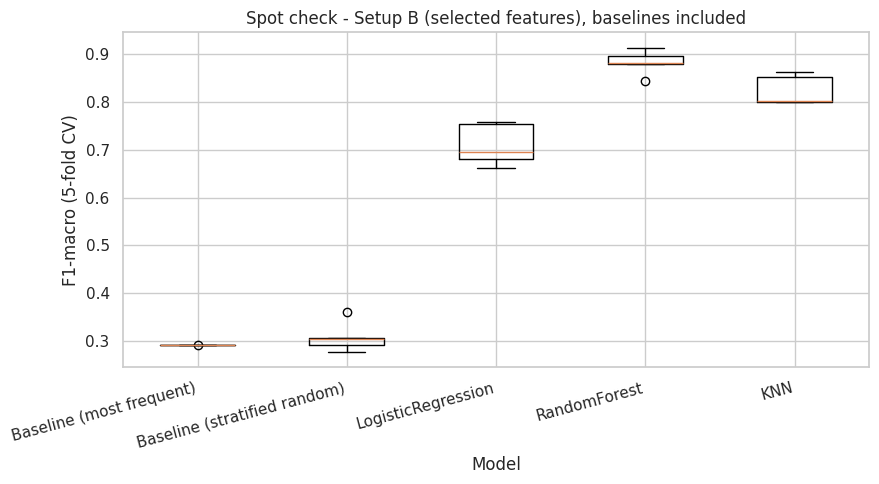

In [37]:
# The baselines ignore the features, so their CV scores are the same as in Setup A
plot_spot_check(spot_check_results_2, baseline_cv_scores, "Spot check - Setup B (selected features), baselines included")

In [38]:
ranking_setup_b = pd.Series({k: v.mean() for k, v in spot_check_results_2.items()}).sort_values(ascending=False)
print("Model ranking (Setup B):")
print(ranking_setup_b)

top_models_setup_b = ranking_setup_b.head(3).index.tolist()

Model ranking (Setup B):


RandomForest          0.882338
KNN                   0.823198
LogisticRegression    0.709824
dtype: float64


## Tuning (Setup B)

In [39]:
tuned_setup_b = tune_models(top_models_setup_b, models_spot2, X_train_sel, y_train)

RandomForest          Best F1-macro (CV): 0.8867  |  Tuning time:   79.5s  |  Best parameters: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}


KNN                   Best F1-macro (CV): 0.8465  |  Tuning time:    0.7s  |  Best parameters: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}


LogisticRegression    Best F1-macro (CV): 0.7148  |  Tuning time:    0.3s  |  Best parameters: {'clf__C': 0.01, 'clf__penalty': 'l2'}


## Final evaluation on the test set (Setup B)

RandomForest (Setup B) - F1-macro on the TEST set: 0.8917  (inference on 423 samples: 19.1 ms)
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.97       330
     Suspect       0.83      0.86      0.85        58
Pathological       0.84      0.89      0.86        35

    accuracy                           0.94       423
   macro avg       0.88      0.90      0.89       423
weighted avg       0.94      0.94      0.94       423



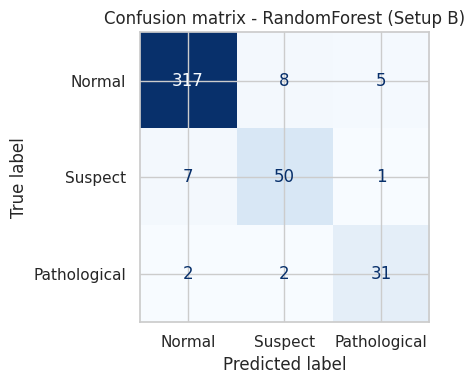

KNN (Setup B) - F1-macro on the TEST set: 0.8158  (inference on 423 samples: 5.3 ms)
              precision    recall  f1-score   support

      Normal       0.95      0.93      0.94       330
     Suspect       0.68      0.72      0.70        58
Pathological       0.78      0.83      0.81        35

    accuracy                           0.90       423
   macro avg       0.80      0.83      0.82       423
weighted avg       0.90      0.90      0.90       423



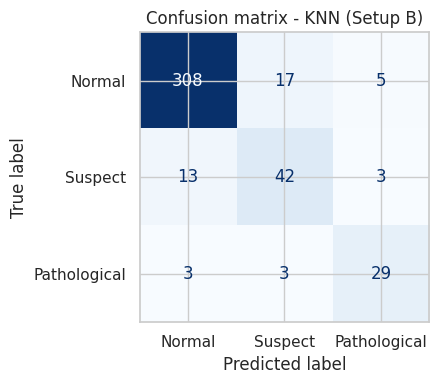

LogisticRegression (Setup B) - F1-macro on the TEST set: 0.7167  (inference on 423 samples: 2.7 ms)
              precision    recall  f1-score   support

      Normal       0.98      0.84      0.90       330
     Suspect       0.50      0.76      0.60        58
Pathological       0.54      0.80      0.64        35

    accuracy                           0.83       423
   macro avg       0.67      0.80      0.72       423
weighted avg       0.88      0.83      0.84       423



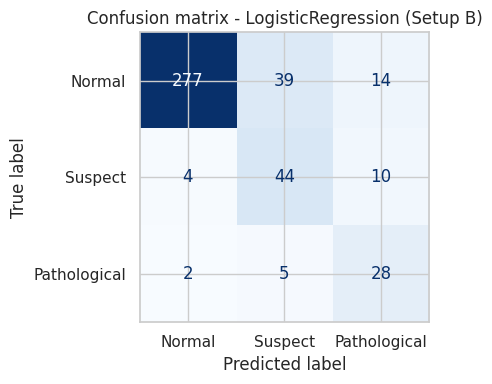

In [40]:
test_results_b = evaluate_on_test(tuned_setup_b, X_test_sel, y_test, title_suffix="(Setup B)")

## Comparison: all features vs selected features
We put in a single table the test-set F1-macro of all the tuned models in both setups, together with the baselines, the recall on the `Pathological` class, and the computational cost (tuning time, final refit time, inference time on the whole test set).

In [41]:
summary_rows = []
def add_rows(results, setup):
    for name, r in results.items():
        summary_rows.append({
            "Setup": setup, "Model": name,
            "F1-macro (test)": round(r["f1_macro"], 4),
            "Recall Pathological": round(r["recall_pathological"], 3),
            "Tuning time (s)": round(r["tuning_time_s"], 1),
            "Refit time (s)": round(r["refit_time_s"], 3),
            "Inference, test set (ms)": round(r["inference_ms"], 1),
        })

add_rows(test_results_a, "A - all features")
add_rows(test_results_b, "B - selected features")
for name, r in baseline_test.items():
    summary_rows.append({
        "Setup": "Baseline", "Model": name,
        "F1-macro (test)": round(r["f1_macro"], 4),
        "Recall Pathological": round(r["recall_pathological"], 3),
        "Tuning time (s)": np.nan, "Refit time (s)": np.nan, "Inference, test set (ms)": np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("F1-macro (test)", ascending=False).reset_index(drop=True)
summary_df

,Setup,Model,F1-macro (test),Recall Pathological,Tuning time (s),Refit time (s),"Inference, test set (ms)"
0,B - selected features,RandomForest,0.8917,0.886,79.5,0.419,19.1
1,A - all features,RandomForest,0.8897,0.857,98.9,0.591,26.2
2,A - all features,KNN,0.8363,0.886,1.0,0.004,8.1
3,B - selected features,KNN,0.8158,0.829,0.7,0.003,5.3
4,A - all features,LogisticRegression,0.7227,0.771,0.9,0.027,1.9
5,B - selected features,LogisticRegression,0.7167,0.800,0.3,0.006,2.7
6,Baseline,Baseline (most frequent),0.2922,0.000,NaN,NaN,NaN
7,Baseline,Baseline (stratified random),0.2775,0.029,NaN,NaN,NaN


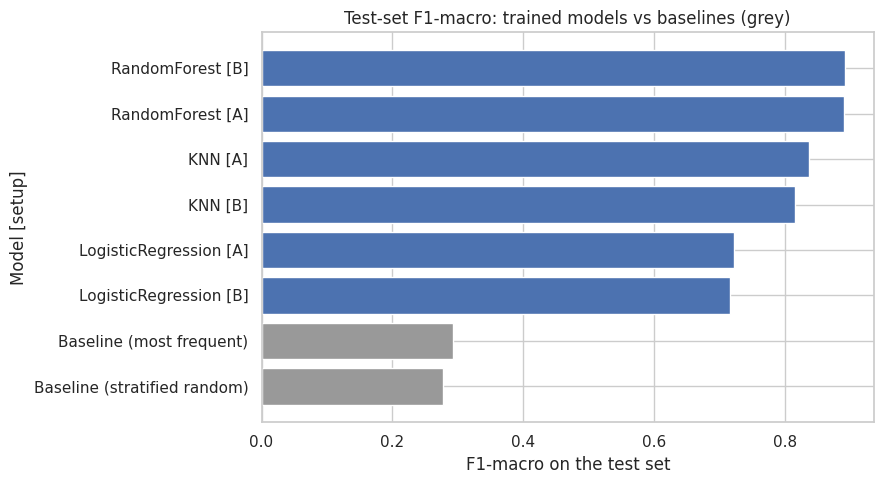

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = summary_df.assign(label=np.where(summary_df["Setup"] == "Baseline", summary_df["Model"],
                                          summary_df["Model"] + " [" + summary_df["Setup"].str[0] + "]"))
colors = ["#999999" if s == "Baseline" else "#4C72B0" for s in plot_df["Setup"]]
ax.barh(plot_df["label"], plot_df["F1-macro (test)"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("F1-macro on the test set")
ax.set_ylabel("Model [setup]")
ax.set_title("Test-set F1-macro: trained models vs baselines (grey)")
plt.tight_layout()
plt.show()

### How to read this comparison

- If **Setup A** (all features) is clearly better, the features discarded in Setup B, although individually less informative according to Mutual Information/Chi-square, still contribute useful information when combined with the others (e.g. feature interactions that a univariate ranking such as MI or Chi2 does not fully capture).
- If **Setup B** achieves comparable (or even slightly better) performance using only 5 features instead of 21, that is a result of great practical value: a simpler model, faster to compute, easier to interpret and, importantly in the company's application context, easier to deploy on low-cost monitoring devices for underserved areas with limited computational/measurement resources, which may not have all 21 sensors/measurements needed to compute the full original feature set.
- In both cases it is worth checking whether the "winning" model in terms of aggregate F1-macro is also the one with the **highest recall on the `Pathological` class** (see the confusion matrix and classification report of each model above, and the `Recall Pathological` column): as discussed in the metrics section, in our clinical context this aspect weighs as much as, if not more than, the aggregate score.
- Every trained model should be read against the grey baselines: the gap between them is the value actually added by learning from the data.

## Seed sensitivity analysis
So far every random component (split, CV folds, model initialization) used one single seed. With some models close to each other in performance, a single seed could produce a ranking that is just an accident of the particular split. To check the robustness of the conclusions we repeat the spot check (all features, default hyperparameters, baselines included) with 5 different seeds. For each seed we draw a new stratified train/test split and new CV folds, compute the 5-fold CV F1-macro on the training part, and also the F1-macro on the corresponding held-out test part. We then look at the mean and standard deviation across seeds, and at whether the ranking of the models changes.

In [43]:
SEEDS = [RANDOM_STATE, 7, 101, 2024, 31337]

def make_models(seed):
    return {
        "LogisticRegression": Pipeline([("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed))]),
        "RandomForest": Pipeline([("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(class_weight="balanced", random_state=seed))]),
        "KNN": Pipeline([("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())]),
        "Baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
        "Baseline (stratified random)": DummyClassifier(strategy="stratified", random_state=seed),
    }

seed_rows = []
for seed in SEEDS:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    cv_seed = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for name, model in make_models(seed).items():
        cv_f1 = cross_validate(model, Xtr, ytr, cv=cv_seed, scoring=SCORING, n_jobs=1)["test_score"].mean()
        model.fit(Xtr, ytr)
        test_f1 = f1_score(yte, model.predict(Xte), average="macro")
        seed_rows.append({"Seed": seed, "Model": name, "F1-macro CV": cv_f1, "F1-macro test": test_f1})

seed_df = pd.DataFrame(seed_rows)

cv_table = seed_df.pivot(index="Model", columns="Seed", values="F1-macro CV")
cv_table["mean"] = cv_table.mean(axis=1)
cv_table["std"] = cv_table[SEEDS].std(axis=1)
print("F1-macro (5-fold CV on the training part), per seed:")
display(cv_table.sort_values("mean", ascending=False).round(4))

test_table = seed_df.pivot(index="Model", columns="Seed", values="F1-macro test")
test_table["mean"] = test_table.mean(axis=1)
test_table["std"] = test_table[SEEDS].std(axis=1)
print("F1-macro on the held-out test part, per seed:")
display(test_table.sort_values("mean", ascending=False).round(4))

real_models = ["LogisticRegression", "RandomForest", "KNN"]
rank_table = seed_df[seed_df["Model"].isin(real_models)].pivot(index="Model", columns="Seed", values="F1-macro CV") \
    .rank(ascending=False).astype(int)
print("Rank of the three models by CV F1-macro (1 = best), per seed:")
display(rank_table)

F1-macro (5-fold CV on the training part), per seed:


Seed,7,101,2024,2718,31337,mean,std
Model,,,,,,,
RandomForest,0.8673,0.8854,0.8814,0.8919,0.8886,0.8829,0.0096
KNN,0.7949,0.8145,0.8066,0.7912,0.8061,0.8027,0.0095
LogisticRegression,0.7820,0.7871,0.7830,0.7863,0.7805,0.7838,0.0028
Baseline (stratified random),0.3419,0.3315,0.3359,0.3088,0.3148,0.3266,0.0142
Baseline (most frequent),0.2919,0.2919,0.2919,0.2919,0.2919,0.2919,0.0000


F1-macro on the held-out test part, per seed:


Seed,7,101,2024,2718,31337,mean,std
Model,,,,,,,
RandomForest,0.8941,0.8970,0.8986,0.8943,0.8571,0.8882,0.0175
KNN,0.8312,0.7784,0.8230,0.7925,0.7978,0.8046,0.0219
LogisticRegression,0.7526,0.7467,0.7610,0.7227,0.7849,0.7536,0.0226
Baseline (stratified random),0.3359,0.3107,0.3443,0.2775,0.3176,0.3172,0.0260
Baseline (most frequent),0.2922,0.2922,0.2922,0.2922,0.2922,0.2922,0.0000


Rank of the three models by CV F1-macro (1 = best), per seed:


Seed,7,101,2024,2718,31337
Model,,,,,
KNN,2,2,2,2,2
LogisticRegression,3,3,3,3,3
RandomForest,1,1,1,1,1


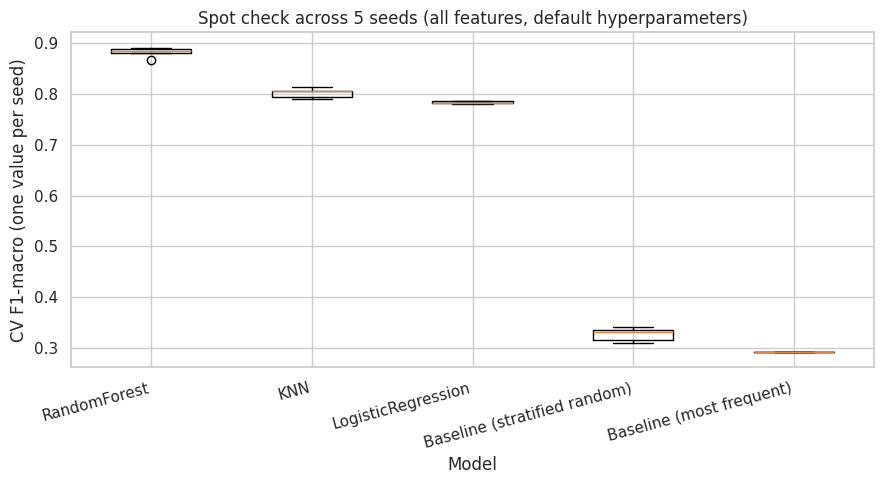

In [44]:
fig, ax = plt.subplots(figsize=(9, 5))
order_models = cv_table.sort_values("mean", ascending=False).index.tolist()
ax.boxplot([seed_df[seed_df["Model"] == m]["F1-macro CV"].values for m in order_models])
ax.set_xticklabels(order_models, rotation=15, ha="right")
ax.set_xlabel("Model")
ax.set_ylabel("CV F1-macro (one value per seed)")
ax.set_title("Spot check across 5 seeds (all features, default hyperparameters)")
plt.tight_layout()
plt.show()

### Seed analysis: findings
- **The ranking is stable.** Random Forest is first, KNN second and Logistic Regression third for all 5 seeds, on the CV score. Random Forest's advantage over KNN (about 0.08 F1-macro on average) is many times larger than the seed-to-seed standard deviation (about 0.01), so it cannot be attributed to a lucky split.
- **The gap between KNN and Logistic Regression is smaller** (about 0.02 in CV, larger on the held-out parts) but its sign is the same in every seed, so this ordering is also reliable.
- **Every model beats the baselines by a wide margin:** the baselines stay around 0.29-0.33 F1-macro, versus 0.78-0.89 for the trained models.
- **The test-set score is noisier than the CV score.** Across seeds the held-out F1-macro of Random Forest ranges from about 0.86 to 0.90 (std $\approx$ 0.02), with the test set containing only 35 Pathological samples. Differences smaller than about 0.02 between two configurations (for example Setup A vs Setup B) should therefore not be over-interpreted.
- The values above use default hyperparameters, so they are close to, but not identical to, the tuned results of the main experiment.

## Limitations and future work
- **Small test set.** The test set has 423 samples, of which only 35 Pathological and 58 Suspect. A single misclassified Pathological case moves its recall by about 3 percentage points, so per-class figures are coarse. The seed analysis shows the test F1-macro varies by roughly $\pm$0.02 across different splits. Confidence intervals (e.g. bootstrap) and repeated or nested cross-validation would quantify this uncertainty better than a single hold-out split.
- **Feature selection is not nested in the cross-validation.** MI and Chi-square scores were computed on the whole training set, so the CV scores of Setup B are slightly optimistic. A cleaner design puts `SelectKBest` inside the `Pipeline`. The test set, never used for selection, is unaffected.
- **Limited set of algorithms.** Only three models were compared. Boosting methods (Gradient Boosting, XGBoost/LightGBM) are the natural next candidates for tabular data like this and were not tested here.
- **Small hyperparameter grids** and a single imbalance strategy (`class_weight='balanced'`). SMOTE, threshold tuning and probability calibration were not explored. For a screening tool, tuning the decision threshold to favour Pathological recall is clinically relevant.
- **Data provenance.** The dataset comes from a single source and its labels are expert annotations. We have no external validation on other hospitals, devices or populations, so real-world performance may be lower.
- **Timings are indicative.** Training and inference times were measured on the machine that ran this notebook (single run, wall-clock) and depend on hardware and on `n_jobs`. They are meant for relative comparison between models.
- **Seed analysis scope.** It covers the spot-check configuration (all features, default hyperparameters). Tuning and feature selection were not repeated for every seed, for computational cost.

## Conclusion

**Best model: Random Forest, in both setups.**

Random Forest led the initial spot check with default settings, and it kept its advantage after tuning, both with all 21 features (test F1-macro = 0.890) and with only the 5 selected features (test F1-macro = 0.892). The ranking Random Forest > KNN > Logistic Regression was identical across the 5 seeds of the sensitivity analysis. The result is consistent with the nature of the data: many features are strongly skewed and have non-linear relationships with the target (as suggested by the boxplots), which is the kind of structure a tree ensemble captures naturally, whereas a linear model such as Logistic Regression struggles (it was the weakest in both setups: about 0.79 and 0.71 CV F1-macro, 0.72 on the test set).

**Comparison with the baselines.** The majority-class baseline obtains a test F1-macro of 0.29 (and a Pathological recall of exactly 0), and the stratified random baseline 0.28, against about 0.89 for Random Forest. This quantifies what the accuracy argument only suggested: a classifier that "learns nothing" looks good on accuracy (~78%) but is useless on the metric that matters here.

**The difference between all features (0.890) and 5 features (0.892) is negligible.** It is well within the seed-to-seed variation of the test score (about $\pm$0.02), so we cannot claim that either setup is better; what we can say is that 5 features carry practically all the predictive information. This has concrete practical value for the business context described at the beginning: it suggests that cheaper and simpler screening tools, which do not need to measure the full set of 21 CTG parameters, could be built for areas with limited diagnostic resources.

**Computational cost.** Random Forest is also the most expensive model, but still cheap in absolute terms: the tuning search took roughly 80-100 seconds on the machine used here (against about 1 second for KNN and Logistic Regression), the final refit well under 1 second, and inference on the 423 test samples about 20-25 ms (about 0.05 ms per sample). Setup B is somewhat cheaper to tune than Setup A. Timings vary by a few seconds between runs. These figures do not change the model choice, but they would become relevant with larger ensembles or on embedded devices.

**The most important number from a clinical point of view: Pathological recall.** Random Forest reaches a recall of 86% with all features and 89% with the 5 selected features on the Pathological class (30 and 31 of the 35 cases). This is the number we care about most in prenatal diagnostics, because a false negative on this class (a pathological fetus classified as normal or suspect) is the clinically most dangerous error the system can make. Given the small number of Pathological cases in the test set, these percentages carry a substantial uncertainty (see Limitations), and 11-14% of Pathological cases still being missed would need to be reduced, for instance by threshold tuning, before any real-world use. This also supports, a posteriori, the choice of F1-macro as guiding metric to avoid neglecting the minority classes: an optimization based on accuracy alone would probably have rewarded models that sacrifice exactly this recall.

**The weak point: the Suspect class.** The intermediate class is the one where the Random Forest performs worst (recall 83% in Setup A and 86% in Setup B, F1 about 0.84-0.85, against 0.97 for Normal). This is understandable: "Suspect" is by definition a clinical middle ground between Normal and Pathological, so it has the greatest intrinsic ambiguity and the least sharp decision boundary in feature space. This can be seen directly in the confusion matrices, where the errors of this class are spread towards both other classes.

**Next steps:** test boosting models, nest the feature selection inside the cross-validation, quantify uncertainty with confidence intervals, and explore threshold tuning to raise Pathological recall (see Limitations and future work).